# E-commerce Sales Analysis

### 🎯 Analysis Goal
Conduct an exploratory analysis of sales data and prepare a report with actionable insights for the Product Manager.

### ✅ Objectives
1. Identify the number of users who made only one purchase.
2. Calculate the average monthly number of undelivered orders due to various reasons.
3. Determine the most frequent purchase day of the week for each product.
4. Calculate the average number of weekly purchases per user, broken down by month.
5. Perform a cohort analysis to identify the user group with the highest third-month retention (from January to December).
6. Build an RFM segmentation model to evaluate customer quality and behavior.

### 📥 Data Loading and Initial Exploration

In [186]:
# Import the necessary libraries
import re
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from urllib.parse import urlencode
from datetime import timedelta

%matplotlib inline

#### Loading data

In [187]:
# Define a function for loading files using Google Drive
def gdrive_download_url(url):
    """
    Converts a public Google Drive link into a direct download link.
    """
    match = re.search(r'/d/([a-zA-Z0-9_-]+)', url)
    if not match:
        raise ValueError("Unable to extract file_id from the URL. Make sure the link follows the format /file/d/FILE_ID/")
    
    file_id = match.group(1)
    return f"https://drive.google.com/uc?export=download&id={file_id}"

In [188]:
# Preparing links for the files to be analyzed
customers_url = gdrive_download_url('https://drive.google.com/file/d/1ZoCOJYbg4AEt6AfC_zruJWDR697I50m2')
orders_url = gdrive_download_url('https://drive.google.com/file/d/1P8uxPKltLurPY6IM2-7EPE4waQYiNnlE')
order_items_url = gdrive_download_url('https://drive.google.com/file/d/1wiDB3FyZr3HglR7u6U3z1scJI28dRBVf')

In [189]:
# Reading data from files and storing them in a DataFrame
# Since we know the date fields, we immediately parse them as "datetime64"
customers = pd.read_csv(customers_url)
orders = pd.read_csv(orders_url, parse_dates=[
                                            'order_purchase_timestamp',
                                            'order_approved_at',
                                            'order_delivered_carrier_date',
                                            'order_delivered_customer_date',
                                            'order_estimated_delivery_date'])
order_items = pd.read_csv(order_items_url, parse_dates=['shipping_limit_date'])

#### Initial data inspection

In [190]:
customers.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


In [191]:
customers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   customer_id               99441 non-null  object
 1   customer_unique_id        99441 non-null  object
 2   customer_zip_code_prefix  99441 non-null  int64 
 3   customer_city             99441 non-null  object
 4   customer_state            99441 non-null  object
dtypes: int64(1), object(4)
memory usage: 3.8+ MB


In [192]:
orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26


In [193]:
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       99441 non-null  object        
 1   customer_id                    99441 non-null  object        
 2   order_status                   99441 non-null  object        
 3   order_purchase_timestamp       99441 non-null  datetime64[ns]
 4   order_approved_at              99281 non-null  datetime64[ns]
 5   order_delivered_carrier_date   97658 non-null  datetime64[ns]
 6   order_delivered_customer_date  96476 non-null  datetime64[ns]
 7   order_estimated_delivery_date  99441 non-null  datetime64[ns]
dtypes: datetime64[ns](5), object(3)
memory usage: 6.1+ MB


In [194]:
order_items.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


In [195]:
order_items.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype         
---  ------               --------------   -----         
 0   order_id             112650 non-null  object        
 1   order_item_id        112650 non-null  int64         
 2   product_id           112650 non-null  object        
 3   seller_id            112650 non-null  object        
 4   shipping_limit_date  112650 non-null  datetime64[ns]
 5   price                112650 non-null  float64       
 6   freight_value        112650 non-null  float64       
dtypes: datetime64[ns](1), float64(2), int64(1), object(3)
memory usage: 6.0+ MB


In [196]:
order_items.describe()

,order_item_id,shipping_limit_date,price,freight_value
count,112650.000000,112650,112650.000000,112650.000000
mean,1.197834,2018-01-07 15:36:52.192685312,120.653739,19.990320
min,1.000000,2016-09-19 00:15:34,0.850000,0.000000
25%,1.000000,2017-09-20 20:57:27.500000,39.900000,13.080000
50%,1.000000,2018-01-26 13:59:35,74.990000,16.260000
75%,1.000000,2018-05-10 14:34:00.750000128,134.900000,21.150000
max,21.000000,2020-04-09 22:35:08,6735.000000,409.680000
std,0.705124,NaN,183.633928,15.806405


All DataFrames were checked for row counts, data formats, and missing values where they would violate business logic.
No additional data processing is required.

### Task 1

**Determine the number of users who made a purchase only once.**  
To begin, we need to define what qualifies as a purchase.

First, let's review all order lifecycle statuses. They can be divided into:

- **Happy path:**
  - `created`  
  - `approved`  
  - `invoiced`  
  - `processing`  
  - `shipped`  
  - `delivered` *(final status)*

- **Non-happy path:**
  - `unavailable` *(final status)*  
  - `canceled` *(final status)*

There are many possible approaches to defining a purchase, and the choice usually depends on the company's internal policy *(it's best to clarify this with a product manager or check internal documentation)*.  
In our case, since we lack that information, I would consider the **moment of payment** as the point of purchase.

However, after reviewing the available statuses, we see that there is **no explicit payment status** — which would typically fall between `invoiced` and `processing`.  
Issuing an invoice doesn't necessarily mean it has been paid, but moving an order to the `processing` stage most likely implies that payment has been received.  
**Therefore, we assume that any order with a `processing` status has already been paid for.**

Since we don't have detailed status logging, we may also use available **timestamps** that are recorded when transitioning between certain stages.

In [197]:
# Let's create a table to view the distribution of orders by status and the completeness of timestamp columns
orders_status_date = orders \
    .groupby(['order_status'], as_index=False) \
    .agg({
        'order_id': 'count',
        'order_purchase_timestamp': 'count',
        'order_approved_at': 'count',
        'order_delivered_carrier_date' : 'count',
        'order_delivered_customer_date' : 'count'
        })
orders_status_date

,order_status,order_id,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date
0,approved,2,2,2,0,0
1,canceled,625,625,484,75,6
2,created,5,5,0,0,0
3,delivered,96478,96478,96464,96476,96470
4,invoiced,314,314,314,0,0
5,processing,301,301,301,0,0
6,shipped,1107,1107,1107,1107,0
7,unavailable,609,609,609,0,0


In [198]:
# Display the number of orders with missing values in the timestamp logging columns
orders[orders.order_status == "delivered"].query('order_delivered_customer_date != order_delivered_customer_date | order_delivered_carrier_date != order_delivered_carrier_date | order_approved_at != order_approved_at').count()

order_id                         23
customer_id                      23
order_status                     23
order_purchase_timestamp         23
order_approved_at                 9
order_delivered_carrier_date     21
order_delivered_customer_date    15
order_estimated_delivery_date    23
dtype: int64

We observe the following:

- Customers can cancel orders at any status.
- The `unavailable` status is only assigned during the `processing` stage.
- According to the column description, `order_approved_at` should contain the time of payment confirmation, but based on previous observations, this timestamp can appear even before the actual payment is made. This could indicate an incorrect column description or logging error.
- For orders in the `delivered` status, we noticed irregularities in the timestamp columns — 23 cases were identified as having errors. However, since payment and shipment were completed in those cases, we will not exclude them from the analysis.

Thus, we define the **moment of purchase as the time when the order is handed over to the logistics service**, and we will use the statuses `delivered` and `shipped`.  
Although customers may still cancel orders in these statuses, the likelihood is very low, so we can safely ignore those cases.

In [199]:
# Enrich the orders table with customer information
orders_n_customers = orders.merge(customers, how='left', on='customer_id')

In [200]:
customers_uniq = orders_n_customers['customer_id'].nunique()

In [201]:
# Determine the number of users who made a purchase only once  
# Display the number of users with orders in the selected statuses
customers_uniq_succes = orders_n_customers \
    .query('order_status == "delivered" | order_status == "shiped"') \
    .groupby('customer_unique_id', as_index=False) \
    .agg({'order_id': 'count'}) \
    .query('order_id == 1') \
    .count()
customers_uniq_succes

customer_unique_id    90557
order_id              90557
dtype: int64

In [202]:
# Percentage of users who made their first purchase
customers_uniq_succes['customer_unique_id'] / customers_uniq * 100

np.float64(91.06605927132672)

#### Result

- Out of 99441 orders placed by 90557 unique users, only about **9% of orders are repeat purchases**.
- This indicates a **high prevalence of one-time purchases** — most customers make only a single order.
- Such a low retention rate may point to:
  - weak post-purchase communication (no upselling, no recommendations)
  - poor first-time experience (logistics, product, support)
  - lack of a loyalty program

**Recommendations**:
- Implement welcome flows, email sequences, and repeat purchase triggers
- Analyze churn reasons (reviews, delivery times, product ratings)

### Task 2

**Determine the average monthly number of orders that are not delivered for various reasons.**

Plan:

1. Identify the main reasons and the conditions for detecting them  
2. Prepare a DataFrame with orders that meet these conditions  
3. Create and populate auxiliary columns (last logged date and reason)  
4. Calculate the total number of failed deliveries  
5. Calculate the number of failed deliveries by reason

Based on the available data, we can identify the following reasons for failed deliveries:

- **Order cancellation** – status `canceled`, logged after order creation, with no transition to the next stages  
- **Cancellation after confirmation/payment** – status `canceled`, logged after order approval/payment, with no transition to the next stages  
- **Cancellation after handing over to the delivery service** – status `canceled`, logged after the order was transferred for shipping, with no further progression  
- **Cancellation after delivery** – status `canceled`, logged after the customer received the order  
- **Item unavailable** – status `unavailable`, logged after the order was sent for picking/packing

In [203]:
# Create a separate DataFrame to prepare the data
unsuccessful_orders = orders.query('order_status == "canceled" | order_status == "unavailable"').copy()

In [204]:
# Add two columns
unsuccessful_orders['last_date'] = None  #дата последнеего залогированного изменения статуса
unsuccessful_orders['reason'] = None  #причины отказов

In [205]:
# Filter orders canceled after being created
condition_order_canceled = (unsuccessful_orders['order_status'] == 'canceled') \
                            & (unsuccessful_orders['order_purchase_timestamp'].notna()) \
                            & (unsuccessful_orders['last_date'].isna())

# Fill the new columns
unsuccessful_orders.loc[condition_order_canceled, 'last_date'] = unsuccessful_orders.loc[condition_order_canceled, 'order_purchase_timestamp']
unsuccessful_orders.loc[condition_order_canceled, 'reason'] = 'Order canceled after creation'

In [206]:
# Filter orders canceled after confirmation/payment
condition_after_payment = (unsuccessful_orders['order_status'] == 'canceled') \
                          & (unsuccessful_orders['order_approved_at'].notna()) \
                          & (unsuccessful_orders['last_date'].isna())

# Fill the new columns
unsuccessful_orders.loc[condition_after_payment, 'last_date'] = unsuccessful_orders.loc[condition_after_payment, 'order_approved_at']
unsuccessful_orders.loc[condition_after_payment, 'reason'] = 'Canceled after confirmation/payment'

In [207]:
# Filter orders canceled after being handed over to the delivery service
condition_after_shipment = (unsuccessful_orders['order_status'] == 'canceled') \
                           & (unsuccessful_orders['order_delivered_carrier_date'].notna()) \
                           & (unsuccessful_orders['last_date'].isna())

# Fill the new columns
unsuccessful_orders.loc[condition_after_shipment, 'last_date'] = unsuccessful_orders.loc[condition_after_shipment, 'order_delivered_carrier_date']
unsuccessful_orders.loc[condition_after_shipment, 'reason'] = 'Canceled after being handed over to delivery'

In [208]:
# Filter orders canceled after being received by the customer
condition_after_delivery = (unsuccessful_orders['order_status'] == 'canceled') \
                           & (unsuccessful_orders['order_delivered_customer_date'].notna()) \
                           & (unsuccessful_orders['last_date'].isna())

# Fill the new columns
unsuccessful_orders.loc[condition_after_delivery, 'last_date'] = unsuccessful_orders.loc[condition_after_delivery, 'order_delivered_customer_date']
unsuccessful_orders.loc[condition_after_delivery, 'reason'] = 'Canceled after customer received the order'

In [209]:
# Filter orders with failure reason: item unavailable
condition_item_unavailable = (unsuccessful_orders['order_status'] == 'unavailable') \
                             & (unsuccessful_orders['order_approved_at'].notna()) \
                             & (unsuccessful_orders['last_date'].isna())

# Fill the new columns
unsuccessful_orders.loc[condition_item_unavailable, 'last_date'] = unsuccessful_orders.loc[condition_item_unavailable, 'order_approved_at']
unsuccessful_orders.loc[condition_item_unavailable, 'reason'] = 'Item unavailable'

In [210]:
# Convert the date column to datetime format in the DataFrame
unsuccessful_orders['last_date'] = pd.to_datetime(unsuccessful_orders['last_date'])

In [211]:
# Add a column with extracted year and month from the `last_date` column
unsuccessful_orders['year_month'] = unsuccessful_orders['last_date'].dt.to_period('M')

In [212]:
# Group the number of orders by month
unsuccessful_orders_by_month = unsuccessful_orders \
    .groupby('year_month', as_index=False) \
    .agg({'order_id': 'count'}) \
    .rename(columns={'order_id': 'order_counts'})

In [213]:
unsuccessful_orders_by_month

,year_month,order_counts
0,2016-09,2
1,2016-10,30
2,2017-01,11
3,2017-02,64
4,2017-03,65
5,2017-04,27
6,2017-05,61
7,2017-06,40
8,2017-07,80
9,2017-08,58


In [214]:
# Calculate the average number of canceled orders
unsuccessful_orders_by_month.drop(columns='year_month').mean()

order_counts    51.416667
dtype: float64

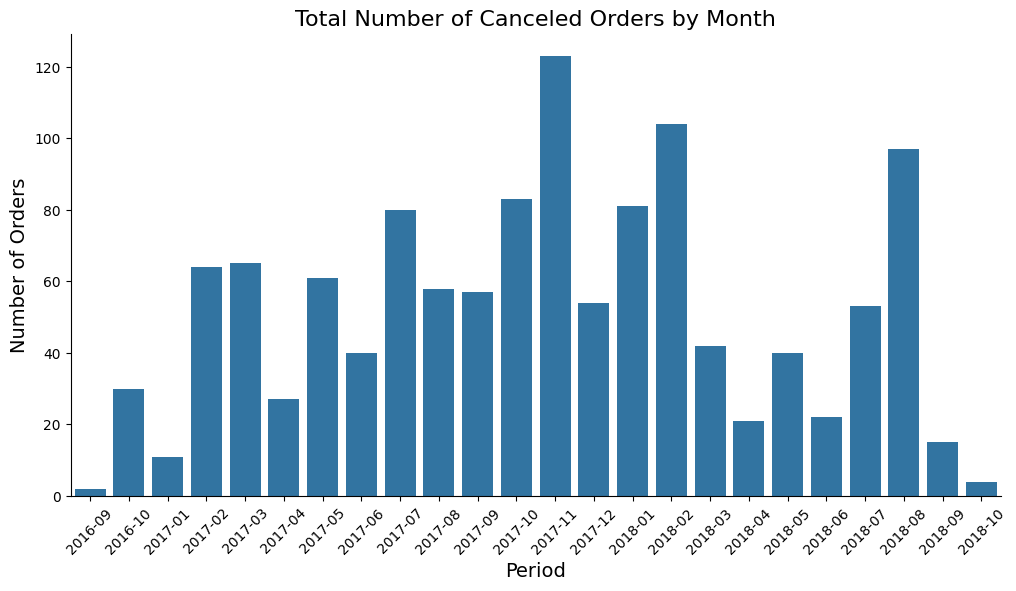

In [267]:
# Plot a chart to visualize the distribution of canceled orders by month
plt.figure(figsize=(12, 6))
sns.barplot(data=unsuccessful_orders_by_month, x='year_month', y='order_counts')

plt.xlabel('Period', fontsize=14)
plt.ylabel('Number of Orders', fontsize=14)
plt.title('Total Number of Canceled Orders by Month', fontsize=16)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.xticks(rotation=45);

In [216]:
# Group the number of orders by reason, then by month
unsuccessful_orders_by_reason_month = unsuccessful_orders \
    .groupby(['reason', 'year_month'], as_index=False) \
    .agg({'order_id': 'count'}) \
    .rename(columns={'order_id': 'order_counts'})

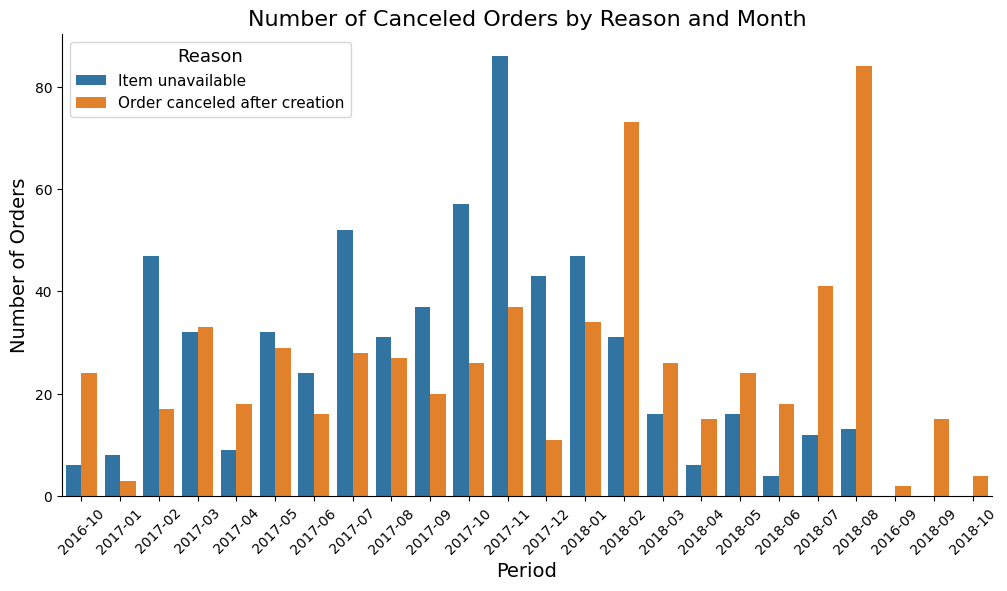

In [268]:
# Plot a chart to visualize the distribution of canceled orders by reason and month
plt.figure(figsize=(12, 6))
sns.barplot(data=unsuccessful_orders_by_reason_month, x='year_month', y='order_counts', hue='reason')

plt.xlabel('Period', fontsize=14)
plt.ylabel('Number of Orders', fontsize=14)
plt.title('Number of Canceled Orders by Reason and Month', fontsize=16)
plt.legend(title='Reason', title_fontsize='13', fontsize='11')
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.xticks(rotation=45);

In [218]:
# A simple mean() method won't work here because it would calculate the average based on the number of reason occurrences
# This would significantly overestimate the actual values
# Let's reshape our DataFrame using pivot and replace missing values with zero
unsuccessful_orders_pivot = unsuccessful_orders \
    .groupby(['reason', 'year_month'], as_index=False) \
    .agg({'order_id': 'count'}) \
    .rename(columns={'order_id': 'order_counts'}) \
    .pivot(index='year_month', columns='reason', values='order_counts').reset_index() \
    .fillna(0)

In [269]:
# Calculate the average monthly number of failed deliveries by reason
unsuccessful_orders_pivot.drop(columns='year_month').mean()

reason
Item unavailable                 25.375000
Order canceled after creation    26.041667
dtype: float64

#### Result

On average, **51.42 orders are canceled per month**, which amounts to over **600 cancellations per year** — representing potential revenue loss and a negative customer experience.

Breakdown by reason:

| Reason                                    | Monthly Average |
|-------------------------------------------|------------------|
| Product unavailable                       | 25.38            |
| Order canceled by customer                | 5.88             |
| Canceled after handover to delivery       | 2.88             |
| Canceled after payment/confirmation       | 17.04            |
| Canceled after delivery to customer       | 0.25             |

**Key observations:**
- The reason **"Product unavailable"** was dominant before 2018 but has declined significantly in recent periods.
- **Cancellations after payment/confirmation** (17.04/month) are now the second most common reason — possibly indicating issues in logistics or customer friction.
- Although less frequent, **cancellations after handover to delivery** and **after receipt** suggest weaknesses in the final stages of order fulfillment and communication.

**Detected anomalies:**
- **August 2018** — a sharp spike in cancellations after payment.
- **February 2018** — a spike in cancellations after handover to the delivery service.

**Recommendations for further analysis:**
- Focus on cancellation data from the **last year**, as user behavior and cancellation reasons have evolved.
- Investigate the causes behind post-payment cancellations to identify friction points in the order process.
- Identify which **product categories** or specific items see the highest cancellation rates — to improve inventory planning or optimize the offer structure.

### Task 3

**For each product, determine the day of the week when it is most frequently purchased.**

The business objective behind this analysis is unclear, so in cases where a product (with a single ID) has multiple days with the same maximum number of purchases, we will return the first such day based on the DataFrame's order.

Plan:

1. Prepare a table by merging sales data with product details  
2. Add a column with the day of the week  
3. Count the number of orders per product for each day of the week  
4. Create a DataFrame with all products and the weekday with the highest number of orders

In [274]:
# In Task 1, we defined the conditions for what qualifies as a sale
sales = orders.query('order_status == "delivered" or order_status == "shipped"')

In [221]:
# Enrich the orders table with product information
# Since we are working with filtered orders, we will use a left join
sales_by_items = sales.merge(order_items, how='left', on='order_id')

In [222]:
# Add a column with the name of the weekday when the order was placed
sales_by_items['purchase_day'] = sales_by_items['order_purchase_timestamp'].dt.day_name()

In [223]:
# Group by product and weekday
# Count the number of orders placed on each day
sales_by_items_weekdays = sales_by_items \
    .groupby(['product_id', 'purchase_day'], as_index=False) \
    .agg({'order_item_id': 'count'}) \
    .rename(columns={'order_item_id': 'order_count'})

In [224]:
# Find the row indices with the maximum number of orders for each product
item_index_max = sales_by_items_weekdays.groupby('product_id')['order_count'].idxmax()

In [275]:
# Display the list of products and the day with the highest number of orders for each product
result_sales_by_items_weekdays = sales_by_items_weekdays.loc[item_index_max][['product_id', 'purchase_day']]
result_sales_by_items_weekdays

,product_id,purchase_day
0,00066f42aeeb9f3007548bb9d3f33c38,Sunday
1,00088930e925c41fd95ebfe695fd2655,Tuesday
2,0009406fd7479715e4bef61dd91f2462,Thursday
3,000b8f95fcb9e0096488278317764d19,Friday
5,000d9be29b5207b54e86aa1b1ac54872,Tuesday
...,...,...
59944,fff6177642830a9a94a0f2cba5e476d1,Saturday
59946,fff81cc3158d2725c0655ab9ba0f712c,Monday
59947,fff9553ac224cec9d15d49f5a263411f,Friday
59951,fffdb2d0ec8d6a61f0a0a0db3f25b441,Tuesday


In [226]:
# Aggregate total sales by each weekday
sales_weekdays = sales_by_items \
    .groupby(['purchase_day'], as_index=False) \
    .agg({'order_item_id': 'count'}) \
    .rename(columns={'order_item_id': 'order_count'})

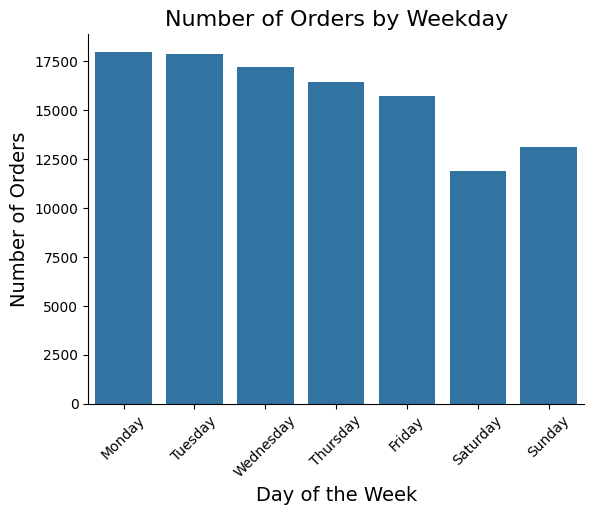

In [276]:
# Plot the number of orders by day of the week
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
sns.barplot(data=sales_weekdays, x='purchase_day', y='order_count', order=day_order)

plt.xlabel('Day of the Week', fontsize=14)
plt.ylabel('Number of Orders', fontsize=14)
plt.title('Number of Orders by Weekday', fontsize=16)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.xticks(rotation=45);

#### Result

A table `result_sales_by_items_weekdays` was created, containing the most popular purchase weekday for each product (`product_id`). The table has **32216 rows × 2 columns**.

Although the aggregated values are accurate, without a specific business objective (e.g., optimizing marketing campaigns, logistics, or procurement), the **interpretation of this data is limited**.

An additional chart was built to show the overall distribution of orders across weekdays.  
It revealed that:
- Orders drop sharply on weekends, especially on **Saturday**.
- Peak activity occurs on **Monday and Wednesday**.

**Possible directions for further analysis:**
- Segment popular products by category to explore **which types of products are purchased on which days**.
- Correlate weekday peaks with marketing activities and ad campaigns.
- Use weekday order patterns to **optimize personalized offers or email campaigns**.

### Task 4

**Determine the average number of purchases per user per week, broken down by month.**

Plan:

1. Prepare a table by merging sales data with customer information  
2. Determine the number of weeks in each month  
3. Calculate the number of purchases per user for each month  
4. Calculate the average number of purchases per week for the months when purchases were made

In [228]:
# Enrich the sales table with customer information
sales_by_customers = sales.merge(customers, how='left', on='customer_id')

In [229]:
# Create auxiliary columns for calculations
# Year and month for grouping monthly orders
sales_by_customers['year_month'] = sales_by_customers['order_purchase_timestamp'].dt.to_period('M')
# Number of weeks in the month
sales_by_customers['weeks_in_month'] = sales_by_customers['order_purchase_timestamp'].dt.days_in_month / 7

In [230]:
sales_by_customers

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,year_month,weeks_in_month
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,2017-10,4.428571
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,af07308b275d755c9edb36a90c618231,47813,barreiras,BA,2018-07,4.428571
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO,2018-08,4.428571
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,7c142cf63193a1473d2e66489a9ae977,59296,sao goncalo do amarante,RN,2017-11,4.285714
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,72632f0f9dd73dfee390c9b22eb56dd6,9195,santo andre,SP,2018-02,4.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
96473,9c5dedf39a927c1b2549525ed64a053c,39bd1228ee8140590ac3aca26f2dfe00,delivered,2017-03-09 09:54:05,2017-03-09 09:54:05,2017-03-10 11:18:03,2017-03-17 15:08:01,2017-03-28,6359f309b166b0196dbf7ad2ac62bb5a,12209,sao jose dos campos,SP,2017-03,4.428571
96474,63943bddc261676b46f01ca7ac2f7bd8,1fca14ff2861355f6e5f14306ff977a7,delivered,2018-02-06 12:58:58,2018-02-06 13:10:37,2018-02-07 23:22:42,2018-02-28 17:37:56,2018-03-02,da62f9e57a76d978d02ab5362c509660,11722,praia grande,SP,2018-02,4.000000
96475,83c1379a015df1e13d02aae0204711ab,1aa71eb042121263aafbe80c1b562c9c,delivered,2017-08-27 14:46:43,2017-08-27 15:04:16,2017-08-28 20:52:26,2017-09-21 11:24:17,2017-09-27,737520a9aad80b3fbbdad19b66b37b30,45920,nova vicosa,BA,2017-08,4.428571
96476,11c177c8e97725db2631073c19f07b62,b331b74b18dc79bcdf6532d51e1637c1,delivered,2018-01-08 21:28:27,2018-01-08 21:36:21,2018-01-12 15:35:03,2018-01-25 23:32:54,2018-02-15,5097a5312c8b157bb7be58ae360ef43c,28685,japuiba,RJ,2018-01,4.428571


In [231]:
# Group sales data by customer and month
sales_by_customers_per_month = sales_by_customers \
    .groupby(['customer_unique_id', 'year_month', 'weeks_in_month'], as_index=False) \
    .agg({'order_id': 'count'}) \
    .rename(columns={'order_id': 'order_count'})

In [232]:
# Add a column to calculate the number of purchases per week
sales_by_customers_per_month['sales_per_week'] = sales_by_customers_per_month['order_count'] / sales_by_customers_per_month['weeks_in_month']

In [233]:
# Display the distribution of the number of purchases based on unique order counts
sales_by_customers_per_month.value_counts('order_count', normalize=True)

order_count
1    0.987153
2    0.012312
3    0.000452
4    0.000074
6    0.000011
Name: proportion, dtype: float64

In [277]:
# Display the distribution of purchases based on the average weekly number of orders
sales_by_customers_per_month.value_counts('sales_per_week', normalize=True)

sales_per_week
0.225806    0.599008
0.233333    0.305534
0.250000    0.082610
0.451613    0.007269
0.466667    0.003393
0.500000    0.001649
0.677419    0.000263
0.700000    0.000126
0.750000    0.000063
1.000000    0.000032
0.903226    0.000021
0.933333    0.000021
1.354839    0.000011
Name: proportion, dtype: float64

#### Result

A table `sales_by_customers_per_month` was created, containing:
- Unique user identifier (`customer_unique_id`);
- Observation year and month (`year_month`);
- Average number of weeks in the month (`weeks_in_month`);
- Number of orders (`order_count`);
- Average weekly sales within the month (`sales_per_week`).

The table has **95194 rows × 5 columns**.

**Key observations:**
- In **98.7%** of cases, users make **only one purchase per month**.
- The average weekly number of purchases per user falls within a narrow range of **0.226 to 0.250** in 98.7% of cases.
- This indicates **low purchase regularity** and a **very stable user behavior pattern** on a monthly scale.

**Possible business insights:**
- Most users purchase sporadically, which should be considered when planning repeat sales strategies and loyalty programs.
- Demand forecasting can rely on stable activity patterns without significant seasonal fluctuations (except for peak months).

### Task 5

**Conduct a cohort analysis of users and identify the cohort with the highest retention rate in the 3rd month, for the period from January to December.**

Plan:

1. Define cohorts  
2. Assign a cohort label to each sale  
3. Calculate the time difference between each sale and the customer's first purchase  
4. Calculate retention  
5. Create a pivot table and apply styling  
6. Identify the cohort with the highest 3rd-month retention

In [235]:
# Copy the sales-by-customer table and select only the necessary columns for cohort analysis
sales_for_cohort = sales_by_customers[['customer_unique_id', 'order_status', 'year_month']].copy()

In [236]:
# Add a cohort column for each sale
sales_for_cohort['cohort'] = sales_for_cohort.groupby("customer_unique_id")["year_month"].transform("min")

In [ ]:
# Calculate the difference between the current purchase date and the customer's first purchase date
sales_for_cohort['cohort_period'] = (sales_for_cohort['year_month'] - sales_for_cohort['cohort']).apply(lambda x: x.n)
sales_for_cohort

,customer_unique_id,order_status,year_month,cohort,cohort_period
0,7c396fd4830fd04220f754e42b4e5bff,delivered,2017-10,2017-09,1
1,af07308b275d755c9edb36a90c618231,delivered,2018-07,2018-07,0
2,3a653a41f6f9fc3d2a113cf8398680e8,delivered,2018-08,2018-08,0
3,7c142cf63193a1473d2e66489a9ae977,delivered,2017-11,2017-11,0
4,72632f0f9dd73dfee390c9b22eb56dd6,delivered,2018-02,2018-02,0
...,...,...,...,...,...
96473,6359f309b166b0196dbf7ad2ac62bb5a,delivered,2017-03,2017-03,0
96474,da62f9e57a76d978d02ab5362c509660,delivered,2018-02,2018-02,0
96475,737520a9aad80b3fbbdad19b66b37b30,delivered,2017-08,2017-08,0
96476,5097a5312c8b157bb7be58ae360ef43c,delivered,2018-01,2018-01,0


In [238]:
# Group the data by cohort and cohort period (month difference)
sales_cohort = sales_for_cohort \
    .groupby(['cohort', 'cohort_period']) \
    .agg({'customer_unique_id': 'count'}) \
    .rename(columns={'customer_unique_id': 'customers'}) \
    .sort_values(by='cohort')

In [239]:
# Calculate retention and store it in a new column
sales_cohort['retention'] = sales_cohort['customers'] / sales_cohort.groupby(["cohort"])["customers"].transform("max")
sales_cohort

customers  retention
cohort  cohort_period                      
2016-09 0                      1   1.000000
2016-10 19                     2   0.007547
        17                     1   0.003774
        15                     1   0.003774
        13                     1   0.003774
...                          ...        ...
2018-06 1                     25   0.004229
        2                     16   0.002707
2018-07 1                     31   0.005161
        0                   6007   1.000000
2018-08 0                   6180   1.000000

[219 rows x 2 columns]

In [240]:
# Add the size of each cohort for better visualization
sales_cohort['size'] = sales_cohort.groupby(["cohort"])["customers"].transform("max")

In [278]:
# Create a pivot table from the cohort DataFrame
sales_cohort_pivot = sales_cohort.pivot_table(index=['cohort', 'size'], columns='cohort_period', values='retention')

# Apply styles for better readability
ur_style = (sales_cohort_pivot
            .style
            .set_caption('User Retention by Month')  # Add a title
            .background_gradient(cmap='plasma')  # Apply a color gradient to cells
            .highlight_null('white')  # Set white background for NaN values
            .format("{:.2%}", na_rep="")  # Format numbers as percentages, replace NaN with empty space
            .set_table_styles([
                                {'selector': 'th', 'props': [('min-width', '50px')]},  # Set minimum width for column headers
                                {'selector': 'tr:hover', 'props': [('background-color', '#ffff99')]},  # Highlight row on hover
                                ])
            )
ur_style

,cohort_period,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,19,20
cohort,size,,,,,,,,,,,,,,,,,,,,
2016-09,1,100.00%,,,,,,,,,,,,,,,,,,,
2016-10,265,100.00%,,,,,,0.38%,,,0.38%,,0.38%,,0.38%,,0.38%,,0.38%,0.75%,0.75%
2016-12,1,100.00%,100.00%,,,,,,,,,,,,,,,,,,
2017-01,749,100.00%,0.27%,0.27%,0.13%,0.40%,0.13%,0.40%,0.13%,0.13%,,0.40%,0.13%,0.67%,0.40%,0.13%,0.13%,0.27%,0.40%,0.13%,
2017-02,1651,100.00%,0.18%,0.30%,0.12%,0.42%,0.12%,0.24%,0.18%,0.12%,0.18%,0.12%,0.30%,0.12%,0.18%,0.12%,0.06%,0.06%,0.18%,,
2017-03,2541,100.00%,0.47%,0.35%,0.47%,0.35%,0.16%,0.16%,0.31%,0.31%,0.08%,0.35%,0.12%,0.20%,0.12%,0.16%,0.24%,0.08%,0.12%,,
2017-04,2284,100.00%,0.66%,0.26%,0.22%,0.26%,0.26%,0.39%,0.31%,0.31%,0.18%,0.26%,0.09%,0.04%,0.04%,0.09%,0.09%,0.18%,,,
2017-05,3517,100.00%,0.48%,0.45%,0.28%,0.28%,0.34%,0.45%,0.14%,0.26%,0.31%,0.26%,0.34%,0.23%,0.03%,0.17%,0.20%,,,,
2017-06,3092,100.00%,0.52%,0.42%,0.42%,0.32%,0.39%,0.36%,0.23%,0.13%,0.19%,0.29%,0.39%,0.16%,0.19%,0.32%,,,,,


In [279]:
# Identify the cohort with the highest 3rd-month retention
max_retention = sales_cohort_pivot[sales_cohort_pivot[3] == sales_cohort_pivot[3].max()].index[0]
max_retention[0]

Period('2017-03', 'M')

#### Result

According to the cohort analysis, the highest retention rate in the 3rd month was observed among users who joined in **March 2017**, reaching only **0.42%** (12 clients from the entire cohort).

**Key observations:**
- On average, no cohort shows a retention rate above 1% at any point of the analysis.
- These figures are significantly below industry benchmarks for e-commerce, where the average 3rd-month retention typically ranges from **16% to 30%**.
- This gap highlights **serious customer retention issues** immediately after the first purchase.

**Analysis limitations:**
- Without additional business context (product types, pricing strategy, acquisition channels, customer journey details), it is impossible to correctly formulate hypotheses about the causes of low retention.
- Further research should include an analysis of the customer's initial experience, UX/UI factors, logistics, and post-purchase communication systems.

**Conclusion:**
Problems with repeat purchases can severely limit business growth and require dedicated attention in both product and marketing strategies.

### Task 6

**Build an RFM segmentation of users for a qualitative audience assessment.**

Plan:

1. Prepare the data for segmentation calculation  
2. Calculate R (Recency) / F (Frequency) / M (Monetary) metrics and compile them into a single table  
3. Define score ranges for each metric  
4. Create target segments and assign them to customers

In [280]:
# Copy the sales-by-customer table and select only the necessary columns for RFM calculations
orders_rfm = sales_by_customers[['customer_unique_id', 'order_id', 'order_purchase_timestamp']].copy()
orders_rfm.head()

,customer_unique_id,order_id,order_purchase_timestamp
0,7c396fd4830fd04220f754e42b4e5bff,e481f51cbdc54678b7cc49136f2d6af7,2017-10-02 10:56:33
1,af07308b275d755c9edb36a90c618231,53cdb2fc8bc7dce0b6741e2150273451,2018-07-24 20:41:37
2,3a653a41f6f9fc3d2a113cf8398680e8,47770eb9100c2d0c44946d9cf07ec65d,2018-08-08 08:38:49
3,7c142cf63193a1473d2e66489a9ae977,949d5b44dbf5de918fe9c16f97b45f8a,2017-11-18 19:28:06
4,72632f0f9dd73dfee390c9b22eb56dd6,ad21c59c0840e6cb83a9ceb5573f8159,2018-02-13 21:18:39


In [281]:
# Prepare order prices separately
order_price = order_items.groupby('order_id', as_index=False).agg({'price': 'sum'})
order_price.head()

,order_id,price
0,00010242fe8c5a6d1ba2dd792cb16214,58.90
1,00018f77f2f0320c557190d7a144bdd3,239.90
2,000229ec398224ef6ca0657da4fc703e,199.00
3,00024acbcdf0a6daa1e931b038114c75,12.99
4,00042b26cf59d7ce69dfabb4e55b4fd9,199.90


In [282]:
# Enrich the orders table with price information
orders_rfm = orders_rfm.merge(order_price, how='left', on='order_id')
orders_rfm.head()

,customer_unique_id,order_id,order_purchase_timestamp,price
0,7c396fd4830fd04220f754e42b4e5bff,e481f51cbdc54678b7cc49136f2d6af7,2017-10-02 10:56:33,29.99
1,af07308b275d755c9edb36a90c618231,53cdb2fc8bc7dce0b6741e2150273451,2018-07-24 20:41:37,118.70
2,3a653a41f6f9fc3d2a113cf8398680e8,47770eb9100c2d0c44946d9cf07ec65d,2018-08-08 08:38:49,159.90
3,7c142cf63193a1473d2e66489a9ae977,949d5b44dbf5de918fe9c16f97b45f8a,2017-11-18 19:28:06,45.00
4,72632f0f9dd73dfee390c9b22eb56dd6,ad21c59c0840e6cb83a9ceb5573f8159,2018-02-13 21:18:39,19.90


In [283]:
# Check the time range of our orders
print('Orders from {} to {}'.format(orders_rfm['order_purchase_timestamp'].min(),
                                    orders_rfm['order_purchase_timestamp'].max()))

Orders from 2016-09-15 12:16:38 to 2018-08-29 15:00:37


In [284]:
# Based on the earlier segment analysis,
# we know that the number of purchases before 2017 was minimal,
# so for the RFM analysis, we will focus on orders from 2017 onwards
sales_rfm = orders_rfm \
    .groupby(['order_id', 'order_purchase_timestamp', 'customer_unique_id']) \
    .agg({'price': 'sum'}) \
    .query('order_purchase_timestamp > "2017-01-01"') \
    .reset_index()
sales_rfm.head()

,order_id,order_purchase_timestamp,customer_unique_id,price
0,00010242fe8c5a6d1ba2dd792cb16214,2017-09-13 08:59:02,871766c5855e863f6eccc05f988b23cb,58.90
1,00018f77f2f0320c557190d7a144bdd3,2017-04-26 10:53:06,eb28e67c4c0b83846050ddfb8a35d051,239.90
2,000229ec398224ef6ca0657da4fc703e,2018-01-14 14:33:31,3818d81c6709e39d06b2738a8d3a2474,199.00
3,00024acbcdf0a6daa1e931b038114c75,2018-08-08 10:00:35,af861d436cfc08b2c2ddefd0ba074622,12.99
4,00042b26cf59d7ce69dfabb4e55b4fd9,2017-02-04 13:57:51,64b576fb70d441e8f1b2d7d446e483c5,199.90


In [285]:
# Define a variable to represent the current moment
# Since we are working with historical data, we will set the analysis date as the last purchase date + 1 day
NOW = sales_rfm['order_purchase_timestamp'].max() + timedelta(days=1)
NOW

Timestamp('2018-08-30 15:00:37')

In [286]:
# Add a column calculating the delta between the current date and the date of the last order
sales_rfm['days_since_order'] = sales_rfm['order_purchase_timestamp'].apply(lambda x: (NOW - x).days)

In [287]:
# Define a variable for the analysis period, taking the full range of the selected timeframe
period = sales_rfm['order_purchase_timestamp'].max() - sales_rfm['order_purchase_timestamp'].min() + timedelta(days=1)

In [288]:
# Calculate recency (the number of days since the customer's last order)
recency = sales_rfm \
    .groupby('customer_unique_id', as_index=False) \
    .agg({'days_since_order': 'min'}) \
    .rename(columns={'days_since_order': 'recency'})

In [289]:
# Calculate frequency (the number of orders within the analysis period)
frequency = sales_rfm[sales_rfm['order_purchase_timestamp'] >= NOW - period] \
    .groupby('customer_unique_id', as_index=False) \
    .agg({'order_id': 'count'}) \
    .rename(columns={'order_id': 'frequency'})

In [290]:
# Calculate monetary value (the total amount spent by the customer)
monetary = sales_rfm[sales_rfm['order_purchase_timestamp'] >= NOW - period] \
    .groupby('customer_unique_id', as_index=False) \
    .agg({'price': 'sum'}) \
    .rename(columns={'price': 'monetary'})

In [291]:
# Combine the calculated values into a single DataFrame
rfm = recency.merge(frequency, on='customer_unique_id', how='left') \
             .merge(monetary, on='customer_unique_id', how='left')
rfm.head()

,customer_unique_id,recency,frequency,monetary
0,0000366f3b9a7992bf8c76cfdf3221e2,112,1,129.90
1,0000b849f77a49e4a4ce2b2a4ca5be3f,115,1,18.90
2,0000f46a3911fa3c0805444483337064,537,1,69.00
3,0000f6ccb0745a6a4b88665a16c9f078,321,1,25.99
4,0004aac84e0df4da2b147fca70cf8255,288,1,180.00


Next, we need to define the thresholds for each metric in order to assign ranks.

In [292]:
# Review the descriptive statistics of the RFM metrics
rfm.describe()

,recency,frequency,monetary
count,93104.000000,93104.000000,93104.000000
mean,236.702924,1.033371,141.573156
std,150.942219,0.209012,215.760366
min,1.000000,1.000000,0.850000
25%,114.000000,1.000000,47.650000
50%,218.000000,1.000000,89.700000
75%,345.000000,1.000000,154.175000
max,602.000000,15.000000,13440.000000


In [293]:
# Calculate quintiles
quintiles = rfm[['recency', 'frequency', 'monetary']].quantile([.2, .4, .6, .8]).to_dict()
quintiles

{'recency': {0.2: 92.0, 0.4: 177.0, 0.6: 268.0, 0.8: 380.0},
 'frequency': {0.2: 1.0, 0.4: 1.0, 0.6: 1.0, 0.8: 1.0},
 'monetary': {0.2: 39.9, 0.4: 69.9, 0.6: 109.9, 0.8: 179.9}}

For `recency` and `monetary`, we can use ranges based on quintiles, but for `frequency`, additional analysis is needed.

In [257]:
# Check the distribution of frequency values
rfm.frequency.value_counts()

frequency
1     90315
2      2562
3       180
4        28
5         9
6         5
7         3
9         1
15        1
Name: count, dtype: int64

For further analysis, the following thresholds were defined:

Here are the tables for each metric.

**Recency (in days)**
| Score | Range From (days) | Range To (days) |
|-------|-------------------|-----------------|
| 5     | 0                 | 92              |
| 4     | 92                | 177             |
| 3     | 177               | 268             |
| 2     | 268               | 380             |
| 1     | 380               | and above       |

**Frequency (number of orders)**
| Score | Range From (orders) | Range To (orders) |
|-------|---------------------|-------------------|
| 3     | 3                   | and above         |
| 2     | 2                   | 2                 |
| 1     | 1                   | 1                 |

**Monetary (in Brazilian real, R$)**
| Score | Range From (R$) | Range To (R$) |
|-------|---------------------|------------------|
| 5     | 179.9                | and above        |
| 4     | 109.9                | 179.9            |
| 3     | 69.9                 | 109.9            |
| 2     | 39.9                 | 69.9             |
| 1     | 0                    | 39.9             |

In [295]:
# Function to assign an R (Recency) score
def r_score(x):
    if x <= quintiles['recency'][.2]:
        return 5
    elif x <= quintiles['recency'][.4]:
        return 4
    elif x <= quintiles['recency'][.6]:
        return 3
    elif x <= quintiles['recency'][.8]:
        return 2
    else:
        return 1

In [296]:
# Function to assign an F (Frequency) score
def f_score(x):
    if x <= 1:
        return 1
    elif x <= 2:
        return 2
    else:
        return 3

In [297]:
# Function to assign an M (Monetary) score
def m_score(x):
    if x <= quintiles['monetary'][.2]:
        return 1
    elif x <= quintiles['monetary'][.4]:
        return 2
    elif x <= quintiles['monetary'][.6]:
        return 3
    elif x <= quintiles['monetary'][.8]:
        return 4
    else:
        return 5

In [298]:
# Add columns with R, F, and M scores using the functions defined earlier
rfm['R'] = rfm['recency'].apply(lambda x: r_score(x))
rfm['F'] = rfm['frequency'].apply(lambda x: f_score(x))
rfm['M'] = rfm['monetary'].apply(lambda x: m_score(x))

In [299]:
# Add a column with the final RFM score
rfm['RFM'] = rfm['R'].map(str) + rfm['F'].map(str) + rfm['M'].map(str)
rfm.head()

,customer_unique_id,recency,frequency,monetary,R,F,M,RFM
0,0000366f3b9a7992bf8c76cfdf3221e2,112,1,129.90,4,1,4,414
1,0000b849f77a49e4a4ce2b2a4ca5be3f,115,1,18.90,4,1,1,411
2,0000f46a3911fa3c0805444483337064,537,1,69.00,1,1,2,112
3,0000f6ccb0745a6a4b88665a16c9f078,321,1,25.99,2,1,1,211
4,0004aac84e0df4da2b147fca70cf8255,288,1,180.00,2,1,5,215


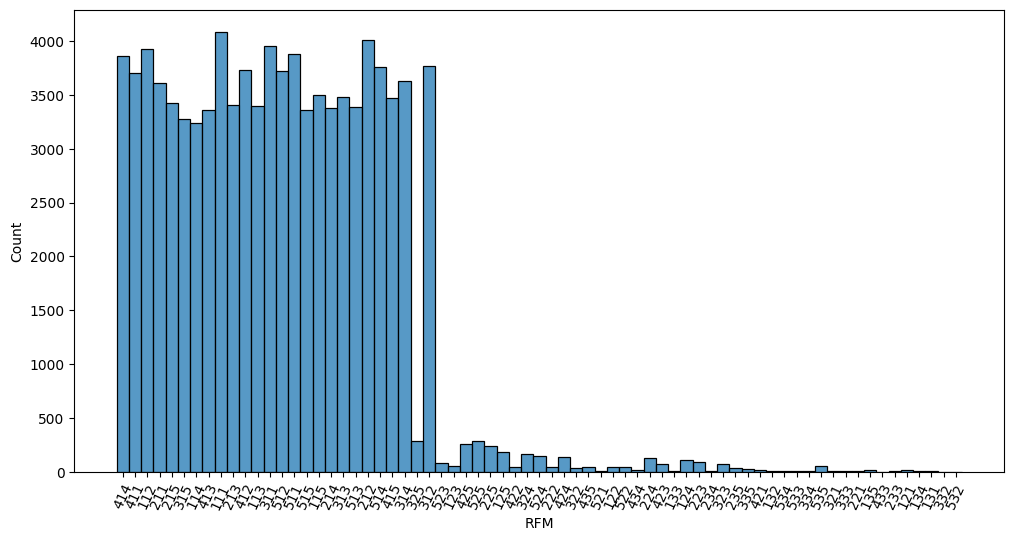

In [300]:
# Visualize how users are distributed across RFM segments
plt.figure(figsize=(12, 6))
sns.histplot(data=rfm, x='RFM')

plt.xticks(rotation=65);

We identified 69 RFM segments, out of which 25 have more than 500 customers.  
All of the mass segments received a frequency score of 1, which indicates that users made only one purchase.  
From our previous analysis, we know that the overwhelming majority of users made just a single purchase.  
It is possible to study users with higher frequency scores separately, but these segments are very small.

In our case, it would be best to focus on the `recency` and `monetary` scores.

Here are the main target segments:

• **Champions**: Recently made a purchase, high spenders.  
• **Big Spenders**: Average time since last purchase, high spenders.  
• **Hibernating Big Spenders**: Long or very long time since last purchase, high spenders.  
• **Recent Average Spenders**: Recently made a purchase, medium spenders.  
• **Promising Average Spenders**: Average time since last purchase, medium spenders.  
• **Hibernating Average Spenders**: Long or very long time since last purchase, medium spenders.  
• **Customers Needing Attention**: Recently made a purchase, low spenders.  
• **At Risk**: Average time since last purchase, low spenders.  
• **Hibernating**: Long or very long time since last purchase, low spenders.

In [301]:
# Prepare the mapping for assigning segment names
segt_map = {
    r'55': 'Champions',
    r'45': 'Big Spenders',
    r'[1-3]5': 'Hibernating Big Spenders',
    r'5[3-4]': 'Recent Average Spenders',
    r'4[3-4]': 'Promising Average Spenders',
    r'[1-3][3-4]': 'Hibernating Average Spenders',
    r'5[1-2]': 'Customers Needing Attention',
    r'4[1-2]': 'At Risk',
    r'[1-3][1-2]': 'Hibernating'
}

# Add a column with the assigned segment name
rfm['Segment'] = rfm['R'].map(str) + rfm['M'].map(str)
rfm['Segment'] = rfm['Segment'].replace(segt_map, regex=True)
rfm.head()

,customer_unique_id,recency,frequency,monetary,R,F,M,RFM,Segment
0,0000366f3b9a7992bf8c76cfdf3221e2,112,1,129.90,4,1,4,414,Promising Average Spenders
1,0000b849f77a49e4a4ce2b2a4ca5be3f,115,1,18.90,4,1,1,411,At Risk
2,0000f46a3911fa3c0805444483337064,537,1,69.00,1,1,2,112,Hibernating
3,0000f6ccb0745a6a4b88665a16c9f078,321,1,25.99,2,1,1,211,Hibernating
4,0004aac84e0df4da2b147fca70cf8255,288,1,180.00,2,1,5,215,Hibernating Big Spenders


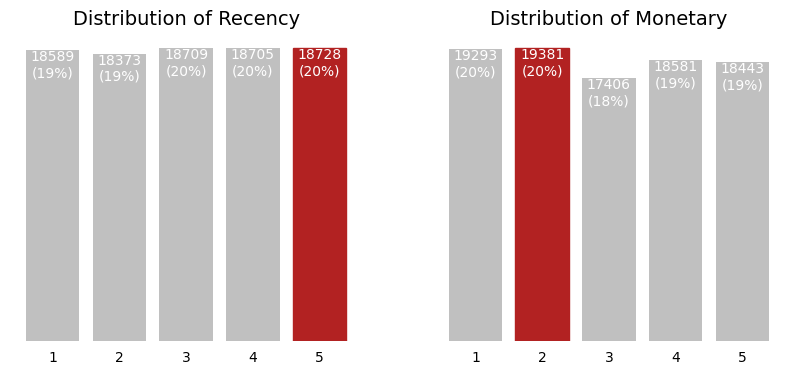

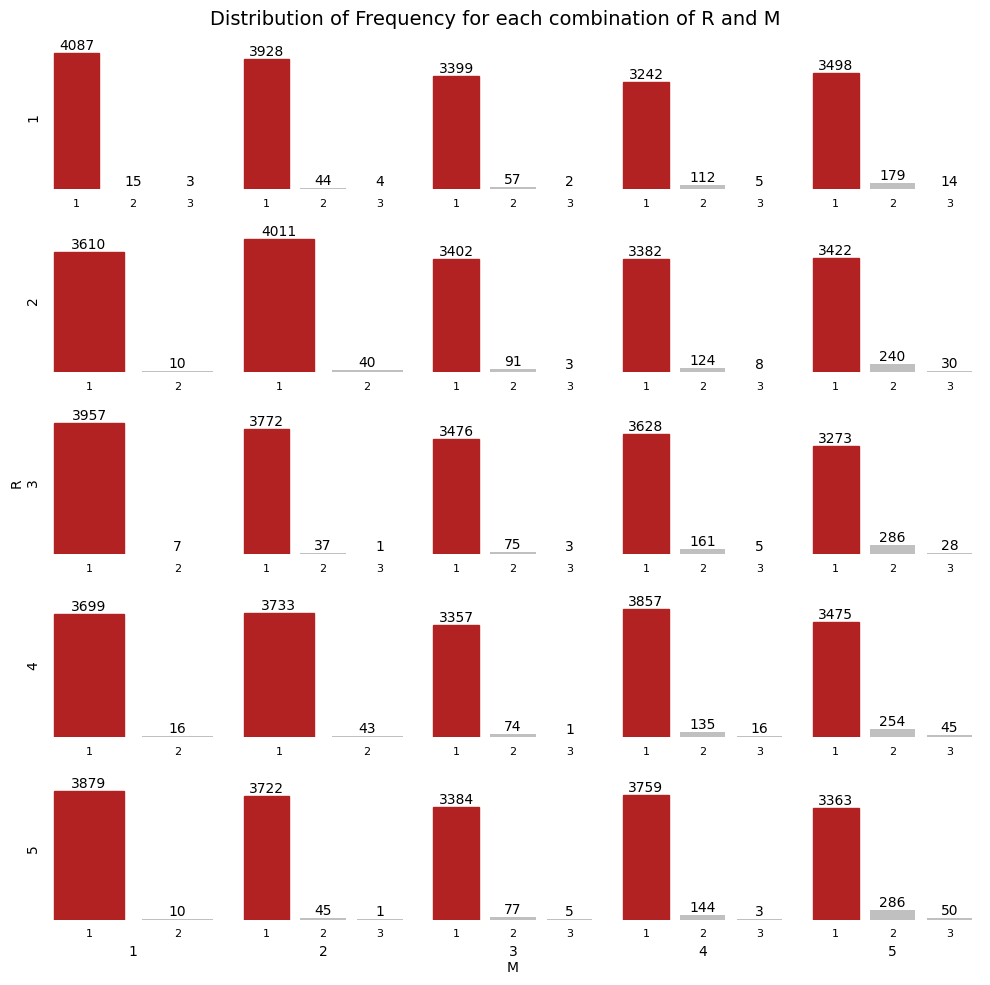

In [302]:
# Plot the distribution of customers by R and M scores
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(10, 4))

for i, p in enumerate(['R', 'M']):
    parameters = {'R': 'Recency', 'M': 'Monetary'}
    y = rfm[p].value_counts().sort_index()
    x = y.index
    ax = axes[i]
    bars = ax.bar(x, y, color='silver')
    ax.set_frame_on(False)
    ax.tick_params(left=False, labelleft=False, bottom=False)
    ax.set_title('Distribution of {}'.format(parameters[p]),
                 fontsize=14)
    for bar in bars:
        value = bar.get_height()
        if value == y.max():
            bar.set_color('firebrick')
        ax.text(bar.get_x() + bar.get_width() / 2,
                value - 5,
                '{}\n({}%)'.format(int(value), int(value * 100 / y.sum())),
                ha='center',
                va='top',
                color='w')

plt.show()

# Plot the distribution of Frequency depending on RM scores
fig, axes = plt.subplots(nrows=5, ncols=5,
                         sharex=False, sharey=True,
                         figsize=(10, 10))

r_range = range(1, 6)
m_range = range(1, 6)
for r in r_range:
    for m in m_range:
        y = rfm[(rfm['R'] == r) & (rfm['M'] == m)]['F'].value_counts().sort_index()
        x = y.index
        ax = axes[r - 1, m - 1]
        bars = ax.bar(x, y, color='silver')
        if r == 5:
            if m == 3:
                ax.set_xlabel('{}\nM'.format(m), va='top')
            else:
                ax.set_xlabel('{}\n'.format(m), va='top')
        if m == 1:
            if r == 3:
                ax.set_ylabel('R\n{}'.format(r))
            else:
                ax.set_ylabel(r)
        ax.set_frame_on(False)
        ax.tick_params(left=False, labelleft=False, bottom=False)
        ax.set_xticks(x)
        ax.set_xticklabels(x, fontsize=8)

        for bar in bars:
            value = bar.get_height()
            if value == y.max():
                bar.set_color('firebrick')
            ax.text(bar.get_x() + bar.get_width() / 2,
                    value,
                    int(value),
                    ha='center',
                    va='bottom',
                    color='k')
fig.suptitle('Distribution of Frequency for each combination of R and M',
             fontsize=14)
plt.tight_layout()
plt.show()

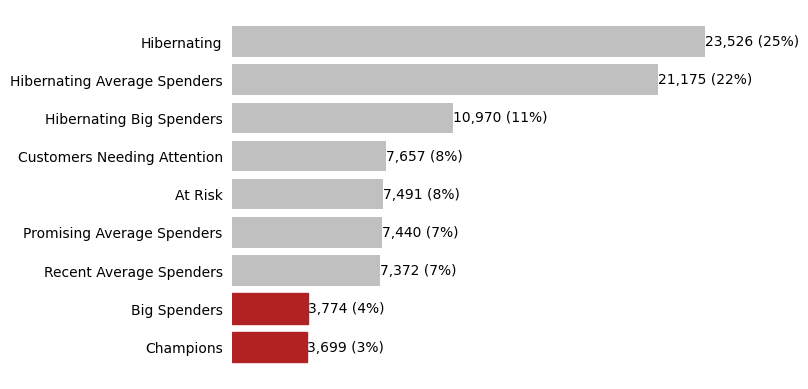

In [303]:
# Plot the distribution of main customer segments and highlight key ones
segments_counts = rfm['Segment'].value_counts().sort_values(ascending=True)

fig, ax = plt.subplots()

bars = ax.barh(range(len(segments_counts)),
               segments_counts,
               color='silver')
ax.set_frame_on(False)
ax.tick_params(left=False,
               bottom=False,
               labelbottom=False)
ax.set_yticks(range(len(segments_counts)))
ax.set_yticklabels(segments_counts.index)

for i, bar in enumerate(bars):
    value = bar.get_width()
    if segments_counts.index[i] in ['Champions', 'Big Spenders']:
        bar.set_color('firebrick')
    ax.text(value,
            bar.get_y() + bar.get_height() / 2,
            '{:,} ({:}%)'.format(int(value),
                                 int(value * 100 / segments_counts.sum())),
            va='center',
            ha='left'
           )

plt.show()

#### Result

##### Definition of scoring ranges

**Recency (in days):**
- 5: less than 92 days
- 4: 92–177 days
- 3: 177–268 days
- 2: 268–380 days
- 1: more than 380 days

**Frequency (number of orders):**
- 3: more than 2 orders
- 2: 2 orders
- 1: 1 order

**Monetary (in Brazilian real, R$)**
- 5: above R$179.9
- 4: R$109.9–R$179.9
- 3: R$69.9–R$109.9
- 2: R$39.9–R$69.9
- 1: below R$39.9

*(Ranges were selected based on the distribution of the sample data.)*


##### Customer segmentation

The following key customer segments were identified:

- **Champions** — recently purchased, high spenders.
- **Big Spenders** — average time since last purchase, high spenders.
- **Hibernating Big Spenders** — long time since last purchase, high spenders.
- **Recent Average Spenders** — recently purchased, medium spenders.
- **Promising Average Spenders** — average time since last purchase, medium spenders.
- **Hibernating Average Spenders** — long time since last purchase, medium spenders.
- **Customers Needing Attention** — recently purchased, low spenders.
- **At Risk** — average time since last purchase, low spenders.
- **Hibernating** — long time since last purchase, low spenders.


##### Overall conclusion

The conducted RFM analysis allowed us to:
- Identify the most valuable customer segments for the business.
- Define target groups for personalized marketing campaigns.
- Build a foundation for hypotheses on increasing purchase frequency, reactivating "sleeping" customers, and raising the average order value.

RFM segmentation opens up broad opportunities for further customer analysis and optimization of the store's client strategy.